# LM basin sweep

In [29]:
import numpy as np
from anser import *
import os
os.chdir("/home/patrick/ansermodelling")
from models.eval import report_error_stats
from models import *
from models.train import pose_errors
import torch
import matplotlib.pyplot as plt
from data.reparametrisation import normal_to_angles, angles_to_normal


In [16]:
coils_global = build_field_generator(N_turns,l,w,s,z_thick,centres,rotations)
f = lambda x : forward_model(x,coils_global)

## Positional Sweep

In [17]:
rng = np.random.default_rng(123)

In [18]:
test_set = np.load("data/test_set.npz")
measurements = test_set["xs"][:200]
poses = test_set["ys"][:200]

In [38]:
ds = np.linspace(0,0.15,20)

In [39]:
poses_pred = np.empty((len(ds), len(poses), 6))
success = np.empty((len(ds), len(poses)), dtype=bool)
n_iters = np.empty((len(ds),len(poses)), dtype = int)

for i, d in enumerate(ds):
    perturbation = rng.normal(size=(len(poses), 3))
    perturbation /= np.linalg.norm(perturbation, axis=-1, keepdims=True)
    perturbation *= d
    pad = np.zeros((len(poses), 3))
    perturbation = np.concatenate([perturbation, pad], axis=-1)
    x0s = normal_to_angles(poses + perturbation)

    for j, x0 in enumerate(x0s):
        pose_pred, xs, suc = lm_solve(f, measurements[j], x0)
        poses_pred[i, j] = angles_to_normal(pose_pred)
        success[i, j] = suc
        n_iters[i,j] = len(xs)
    print(f"d = {d*1000:.1f} mm done")
    

d = 0.0 mm done
d = 7.9 mm done
d = 15.8 mm done
d = 23.7 mm done
d = 31.6 mm done
d = 39.5 mm done
d = 47.4 mm done
d = 55.3 mm done
d = 63.2 mm done
d = 71.1 mm done
d = 78.9 mm done
d = 86.8 mm done
d = 94.7 mm done
d = 102.6 mm done
d = 110.5 mm done
d = 118.4 mm done
d = 126.3 mm done
d = 134.2 mm done
d = 142.1 mm done
d = 150.0 mm done


In [40]:
success.mean(axis = -1)

array([0.355, 0.99 , 0.99 , 0.965, 0.945, 0.92 , 0.88 , 0.885, 0.855,
       0.89 , 0.86 , 0.855, 0.89 , 0.83 , 0.85 , 0.825, 0.855, 0.815,
       0.815, 0.78 ])

In [41]:
n_iters.mean(axis = -1)

array([ 1.355,  7.165,  8.105, 10.725, 13.24 , 16.24 , 19.48 , 19.085,
       20.875, 20.03 , 21.12 , 21.72 , 19.215, 21.015, 22.76 , 24.715,
       21.025, 24.48 , 22.305, 28.15 ])

In [42]:
?report_error_stats

Signature:
report_error_stats(
    pred: numpy.ndarray,
    true: numpy.ndarray,
    success: numpy.ndarray,
    eps_x=1.0,
    eps_n=1.0,
) -> None
Docstring: <no docstring>
File:      ~/ansermodelling/models/eval.py
Type:      function

In [48]:
exs = np.empty((len(ds), len(poses)))
ens = np.empty((len(ds), len(poses)))

true_t = torch.as_tensor(poses, dtype=torch.float64)

for i in range(len(ds)):
    pred_t = torch.as_tensor(poses_pred[i], dtype=torch.float64)
    ex, en = pose_errors(pred_t, true_t)
    exs[i], ens[i] = ex.numpy(), en.numpy()

converged = (exs < 1.0) & (ens < 1.0)
rate = converged.mean(axis=-1)

In [50]:
rate

array([1.   , 0.985, 0.98 , 0.96 , 0.94 , 0.915, 0.88 , 0.885, 0.845,
       0.885, 0.85 , 0.855, 0.88 , 0.84 , 0.84 , 0.825, 0.845, 0.815,
       0.81 , 0.785])

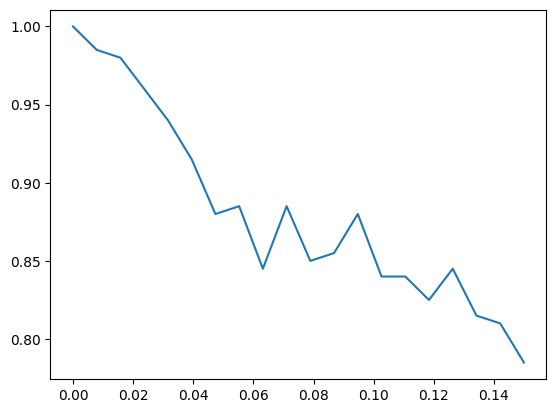

In [51]:
plt.plot(ds,rate)

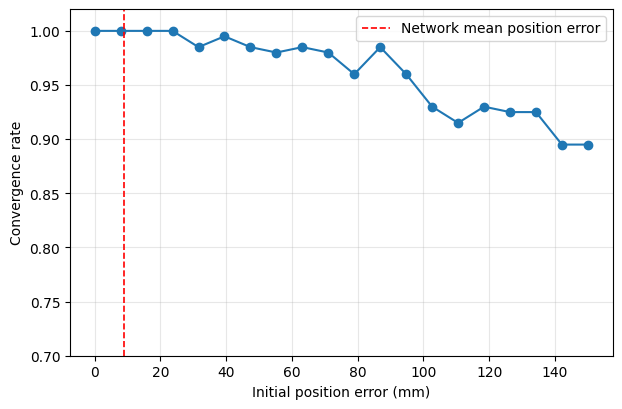

In [61]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ds * 1000, rate, marker="o", lw=1.5)
ax.axvline(8.77, color="r", ls="--", lw=1.2,
           label="Network mean position error")
ax.set_xlabel("Initial position error (mm)")
ax.set_ylabel("Convergence rate")
ax.set_ylim(0.7, 1.02)
ax.legend()
ax.grid(alpha=0.3)

## Orientation sweep

In [55]:
alphas = np.linspace(0, np.pi/2, 20)      # 0 to 90 degrees

poses_pred = np.empty((len(alphas), len(poses), 6))
n_true = poses[:,3:]
for i, a in enumerate(alphas):
    v = rng.normal(size=(len(poses), 3))
    v -= (v * n_true).sum(-1, keepdims=True) * n_true
    v /= np.linalg.norm(v, axis=-1, keepdims=True)
    n_pert = np.cos(a) * n_true + np.sin(a) * v

    x0s_6 = np.concatenate([poses[:, :3], n_pert], axis=-1)
    x0s = normal_to_angles(x0s_6)

    for j, x0 in enumerate(x0s):
        pose_pred, xs, _ = lm_solve(f, measurements[j], x0)
        poses_pred[i, j] = angles_to_normal(pose_pred)
    print(f"alpha = {np.degrees(a):.1f} deg done")


alpha = 0.0 deg done
alpha = 4.7 deg done
alpha = 9.5 deg done
alpha = 14.2 deg done
alpha = 18.9 deg done
alpha = 23.7 deg done
alpha = 28.4 deg done
alpha = 33.2 deg done
alpha = 37.9 deg done
alpha = 42.6 deg done
alpha = 47.4 deg done
alpha = 52.1 deg done
alpha = 56.8 deg done
alpha = 61.6 deg done
alpha = 66.3 deg done
alpha = 71.1 deg done
alpha = 75.8 deg done
alpha = 80.5 deg done
alpha = 85.3 deg done
alpha = 90.0 deg done


In [56]:
exs = np.empty((len(ds), len(poses)))
ens = np.empty((len(ds), len(poses)))

true_t = torch.as_tensor(poses, dtype=torch.float64)

for i in range(len(ds)):
    pred_t = torch.as_tensor(poses_pred[i], dtype=torch.float64)
    ex, en = pose_errors(pred_t, true_t)
    exs[i], ens[i] = ex.numpy(), en.numpy()

converged = (exs < 1.0) & (ens < 1.0)
rate = converged.mean(axis=-1)

In [57]:
rate

array([1.   , 1.   , 1.   , 1.   , 0.985, 0.995, 0.985, 0.98 , 0.985,
       0.98 , 0.96 , 0.985, 0.96 , 0.93 , 0.915, 0.93 , 0.925, 0.925,
       0.895, 0.895])

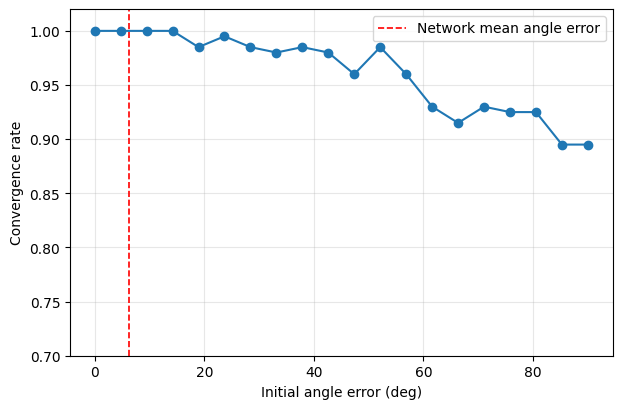

In [62]:

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(angles * 180/np.pi, rate, marker="o", lw=1.5)
ax.axvline(6.2, color="r", ls="--", lw=1.2,
           label="Network mean angle error")
ax.set_xlabel("Initial angle error (deg)")
ax.set_ylabel("Convergence rate")
ax.set_ylim(0.7, 1.02)
ax.legend()
ax.grid(alpha=0.3)